In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import time

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print(x_train.shape, y_train.shape)

(50000, 32, 32, 3) (50000, 10)


In [ ]:
def build_alexnet():
    model = models.Sequential([
        layers.Conv2D(96, (3,3), strides=1, activation='relu', input_shape=(32,32,3), padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(384, (3,3), activation='relu', padding='same'),
        layers.Conv2D(384, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(10, activation='softmax')
    ])
    return model

In [4]:
model = build_alexnet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 96)        2688      
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 96)       384       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 96)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 256)       221440    
                                                                 
 batch_normalization_1 (Batc  (None, 16, 16, 256)      1024      
 hNormalization)                                                 
                                                        

In [5]:
start_time = time.time()

history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time: {training_time:.2f} seconds")

Epoch 1/30
352/352 [==============================] - 20s 45ms/step - loss: 1.4344 - accuracy: 0.4768 - val_loss: 2.4181 - val_accuracy: 0.1934
Epoch 2/30
352/352 [==============================] - 15s 42ms/step - loss: 0.9691 - accuracy: 0.6547 - val_loss: 0.9155 - val_accuracy: 0.6744
Epoch 3/30
352/352 [==============================] - 15s 43ms/step - loss: 0.7424 - accuracy: 0.7381 - val_loss: 0.8245 - val_accuracy: 0.7134
Epoch 4/30
352/352 [==============================] - 15s 44ms/step - loss: 0.5813 - accuracy: 0.7954 - val_loss: 0.7858 - val_accuracy: 0.7376
Epoch 5/30
352/352 [==============================] - 17s 48ms/step - loss: 0.4281 - accuracy: 0.8522 - val_loss: 0.6707 - val_accuracy: 0.7750
Epoch 6/30
352/352 [==============================] - 17s 48ms/step - loss: 0.2991 - accuracy: 0.8954 - val_loss: 0.7133 - val_accuracy: 0.7718
Epoch 7/30
352/352 [==============================] - 17s 48ms/step - loss: 0.1978 - accuracy: 0.9320 - val_loss: 0.7680 - val_accuracy:

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 75.21%
Test Loss: 1.4490


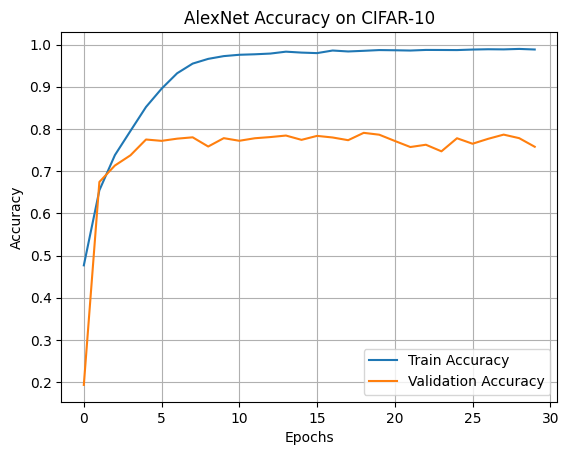

In [7]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('AlexNet Accuracy on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

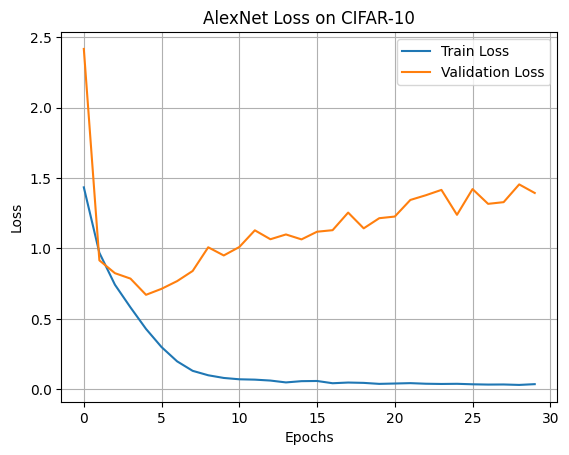

In [8]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('AlexNet Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
print(f"Total Parameters: {model.count_params():,}")

Total Parameters: 36,926,730
